In [1]:
using Pkg 
Pkg.activate("..")

  Activating project at `~/code/PhasorNetworks.jl`


In [2]:
include("../src/PhasorNetworks.jl")
using .PhasorNetworks, Plots, DifferentialEquations

In [3]:
using Lux, MLUtils, MLDatasets, OneHotArrays, Statistics, Test, LuxCUDA
using Random: Xoshiro, AbstractRNG
using Base: @kwdef
using Zygote: withgradient
using Optimisers, ComponentArrays
using Statistics: mean
using LinearAlgebra: diag
using PhasorNetworks: bind
using Distributions: Normal
using DifferentialEquations: Heun, Tsit5

[ Info: Precompiling PhasorNetworks [c32d742c-e486-48f1-8804-9f6fb4d3f42c] (cache misses: include_dependency fsize change (2), mismatched flags (14))


# Static attention product

In [4]:
rng = Xoshiro(42)

Xoshiro(0xa379de7eeeb2a4e8, 0x953dccb6b532b3af, 0xf597b8ff8cfd652a, 0xccd7337c571680d1, 0xc90c4a0730db3f7e)

In [5]:
cdev = cpu_device()
gdev = gpu_device()

(::CUDADevice{Nothing}) (generic function with 1 method)

In [6]:
q = random_symbols((4, 64, 512), rng)
k = random_symbols((4, 64, 512), rng)
v = random_symbols((4, 64, 512), rng);

In [7]:
q, k, v = (q, k, v) .|> gdev

(Float32[-0.091034174 0.33917928 … 0.7826654 0.24790657; -0.65285087 -0.4828291 … -0.72534704 -0.89736307; 0.32237244 -0.7229662 … -0.54584837 -0.9041953; -0.35667682 -0.6671227 … -0.5309526 -0.61719847;;; 0.71608126 -0.45675933 … 0.467353 -0.09929335; -0.20839036 0.4270022 … -0.6866617 0.25354612; 0.49520743 0.9320961 … -0.58690906 -0.18206036; -0.16922593 -0.6162381 … -0.030122042 -0.86962867;;; -0.82497346 0.56005025 … 0.6548073 -0.1595478; -0.8821025 -0.64632916 … -0.25539947 -0.85281885; -0.9143027 0.7800586 … -0.19363868 0.70287323; 0.89194727 -0.21503568 … 0.33076096 -0.32862306;;; … ;;; -0.4953779 0.7469375 … 0.24980557 -0.00034451485; -0.04199195 0.0984118 … -0.8751414 0.27139044; 0.7955264 -0.92993736 … 0.32659996 -0.030631185; -0.47544432 -0.3583634 … -0.10030997 -0.30300975;;; -0.56644356 -0.9054899 … -0.7531769 -0.050798535; -0.11661649 0.68115926 … -0.121946454 -0.7811066; -0.06485784 0.031767726 … 0.15479612 -0.040259123; 0.11169076 0.19812703 … -0.07139909 0.8895699;;; 

In [10]:
import .PhasorNetworks: attend

In [11]:
scores = similarity_outer(q, k, dims=2) |> cdev;

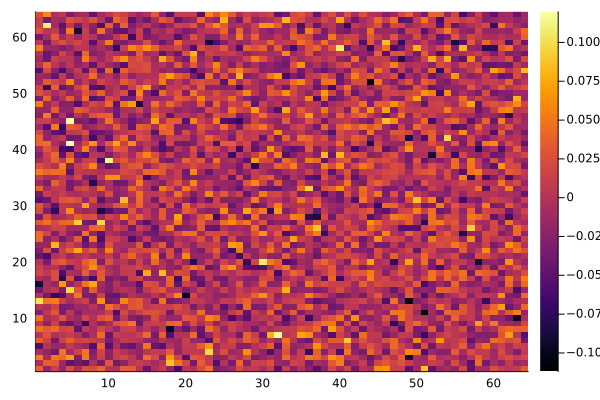

In [12]:
heatmap(scores[1,1,:,:])

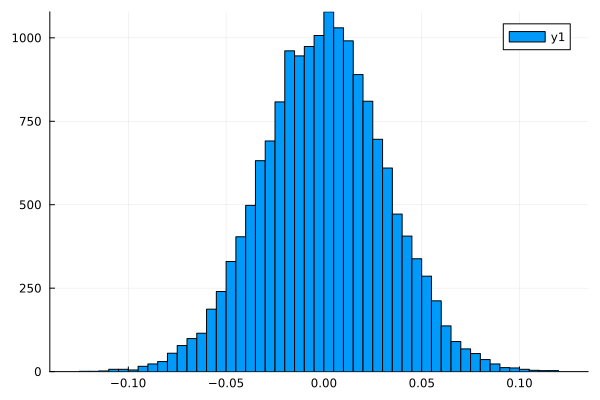

In [13]:
histogram(vec(scores))

In [14]:
atv = attend(q, k, v) |> cdev

512×64×4 Array{Float32, 3}:
[:, :, 1] =
  0.0426324  -0.148216   -0.875809    0.844507   …   0.223674     0.589517
 -0.850097   -0.976029   -0.370318   -0.852294      -0.803478     0.136526
  0.118283   -0.6867     -0.412272    0.805263       0.693281    -0.557361
  0.491888    0.624371    0.264883    0.932288       0.49226      0.0912425
 -0.497161   -0.0790666   0.321959    0.862602      -0.65194      0.886512
 -0.518623   -0.60517     0.282422    0.0722172  …  -0.940595     0.350667
 -0.82087     0.787484    0.844958    0.427416      -0.960971     0.312018
 -0.166732   -0.29782     0.0966803  -0.413759      -0.698675    -0.982062
 -0.0847524   0.964596   -0.34016    -0.51954       -0.70812      0.860443
  0.107716    0.262509    0.530082    0.18005       -0.0205382    0.216402
 -0.608064   -0.537923    0.865669   -0.0870014  …  -0.362894     0.302964
  0.761584   -0.830193    0.796277    0.0344477      0.988279     0.827519
 -0.763287   -0.791506    0.861058    0.580303      -0.0069

Spiking execution

In [15]:
spk_args = SpikingArgs()

Neuron parameters: Period 1.0 (s)
Current kernel duration: 0.01 (s)
Threshold: 0.001 (V)


In [16]:
qt = phase_to_train(q, spk_args=spk_args)
kt = phase_to_train(k, spk_args=spk_args)
vt = phase_to_train(v, spk_args=spk_args);

In [17]:
tspan = (0.0, 10.0)

(0.0, 10.0)

In [18]:
sol_x = oscillator_bank(qt, tspan = tspan, spk_args = spk_args) 

retcode: Success
Interpolation: 3rd order Hermite
t: 1001-element Vector{Float32}:
  0.0
  0.01
  0.02
  0.03
  0.04
  0.049999997
  0.059999995
  0.06999999
  0.07999999
  0.08999999
  0.09999999
  0.109999985
  0.11999998
  ⋮
  9.890131
  9.900131
  9.910131
  9.920132
  9.930132
  9.940132
  9.950132
  9.960133
  9.970133
  9.980133
  9.990133
 10.0
u: 1001-element Vector{CuArray{ComplexF32, 3, CUDA.DeviceMemory}}:
 [0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im;;; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im;;; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.

In [19]:
typeof(sol_x)

ODESolution{ComplexF32, 4, Vector{CuArray{ComplexF32, 3, CUDA.DeviceMemory}}, Nothing, Nothing, Vector{Float32}, Vector{Vector{CuArray{ComplexF32, 3, CUDA.DeviceMemory}}}, Nothing, ODEProblem{CuArray{ComplexF32, 3, CUDA.DeviceMemory}, Tuple{Float32, Float32}, false, SciMLBase.NullParameters, ODEFunction{false, SciMLBase.AutoSpecialize, Main.PhasorNetworks.var"#dzdt#77"{SpikingArgs, SpikeTrainGPU, Main.PhasorNetworks.var"#27#28"{Float32, Float32}}, LinearAlgebra.UniformScaling{Bool}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, typeof(SciMLBase.DEFAULT_OBSERVED), Nothing, Nothing, Nothing, Nothing}, Base.Pairs{Symbol, Union{}, Tuple{}, @NamedTuple{}}, SciMLBase.StandardODEProblem}, Heun{typeof(OrdinaryDiffEqCore.trivial_limiter!), typeof(OrdinaryDiffEqCore.trivial_limiter!), Static.False}, OrdinaryDiffEqCore.InterpolationData{ODEFunction{false, SciMLBase.AutoSpecialize, Main.PhasorNetworks.var"#dzdt#77"{SpikingArgs, SpikeTrainGPU, Ma

In [20]:
sol_x.u

1001-element Vector{CuArray{ComplexF32, 3, CUDA.DeviceMemory}}:
 [0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im;;; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im;;; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im;;; … ;;; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0

In [21]:
sol_y = oscillator_bank(kt, tspan = tspan, spk_args = spk_args) ;

In [23]:
using CUDA

In [52]:
function interference_kernel(A, B, output, X, M, N, D)
    # Thread indices for matrix dimensions
    m = (blockIdx().x - 1) * blockDim().x + threadIdx().x
    n = (blockIdx().y - 1) * blockDim().y + threadIdx().y
    # Batch dimension from grid z-axis
    x = blockIdx().z

    if x <= X && m <= M && n <= N
        acc = 0.0f0
        @inbounds for d in 1:D
            # Load complex values from batch tensors
            a = A[x, m, d]
            b = B[x, n, d]
            
            # Complex addition and magnitude calculation
            sum_real = real(a) + real(b)
            sum_imag = imag(a) + imag(b)
            interference = sqrt(sum_real^2 + sum_imag^2)
            
            # Clamp and transform
            magnitude = clamp(interference, 0.0f0, 2.0f0)
            half_angle = acos(0.5f0 * magnitude)
            sim = cos(2.0f0 * half_angle)
            acc += sim
        end
        # Transpose output dimensions to X×N×M
        output[x, n, m] = acc / D
    end
    return
end

interference_kernel (generic function with 1 method)

In [54]:
import .PhasorNetworks: similarity_outer

In [55]:
function similarity_outer(A::CuArray{ComplexF32,3}, B::CuArray{ComplexF32,3})
    X, M, D = size(A)
    X_B, N, D_B = size(B)
    @assert X == X_B "Batch size mismatch (X_A=$X vs X_B=$X_B)"
    @assert D == D_B "Feature dimension mismatch (D_A=$D vs D_B=$D_B)"

    output = CUDA.zeros(Float32, X, N, M)
    
    # Kernel configuration (256 threads/block in x-y plane)
    threads = (16, 16, 1)
    blocks = (ceil(Int, M/16), ceil(Int, N/16), X)
    
    @cuda threads=threads blocks=blocks interference_kernel(A, B, output, X, M, N, D)
    synchronize()
    return output
end

similarity_outer (generic function with 4 methods)

In [ ]:
ua = normalize_potential.(sol_x.u)
ub = normalize_potential.(sol_y.u);

TypeError: TypeError: in typeassert, expected REPL.REPLCompletions.MethodCompletion, got a value of type REPL.REPLCompletions.TextCompletion

In [66]:
size(ub)

(1001,)

In [68]:
sou = similarity_outer.(ua, ub)

1001-element Vector{CuArray{Float32, 3, CUDA.DeviceMemory}}:
 [-1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0;;; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0;;; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0;;; … ;;; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0;;; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0;;; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0]
 [-0.73437786 -0.7587917 … -0.75488657 -0.75293446; -0.7705107 -0.74805224 … -0.7724621 -0.7587909; -0.75683904 -0.8066417 … -0.7919939 -0.76269937; -0.7607454 -0.7705101 … -0.7568391 -0.783206;;; -0.71973425 -0.73633033 … -0.7656266 -0.74414456; -0.7753912 -0.76660544 … -0.76758105 -0.75976896; -0.75586367 -0.8017607 … -0.8007849 -0.76758194; -0.75293094 -0.7627002 

In [ ]:
similarity_outer

In [22]:
import .PhasorNetworks: normalize_potential, interference_similarity

In [ ]:
function similarity_kernel(u_q::CuArray, u_k::CuArray, compare_dims::Int, reduce_dim::Int)
    u_q = normalize_potential.(u_q)
    u_k = normalize_potential.(u_k)
    interference = [abs.(u_qs .+ u_ks) for u_qs in eachslice(u_q, dims=compare_dims), u_ks in eachslice(u_k, dims=compare_dims)]
    #move drop dim down by one to compensate for slice
    similarity = interference_similarity.(interference, dim=reduce_dim-1) |> stack
    return similarity
end

similarity_kernel (generic function with 1 method)

In [36]:
sko = similarity_kernel(sol_x.u[100], sol_y.u[100], 2, 3)

4×64×64 CuArray{Float64, 3, CUDA.DeviceMemory}:
[:, :, 1] =
  0.0373854  -0.00725735   0.0559568   …   0.0131751   0.0132285   0.023945
 -0.0405589  -0.00982924   0.00867936     -0.0634867  -0.0451954   0.00181606
  0.0235316   0.0576424    0.0194723       0.014446   -0.00304154  0.0208356
 -0.0193738  -0.0212066   -0.0503169      -0.0199294   0.0190853   0.0442468

[:, :, 2] =
 -0.020606     0.0359685    -0.00927545  …  -0.0367544   0.0579885
 -0.0156518   -0.00674498    0.0210908       0.00743601  0.000957451
 -0.00867989   0.00835108   -0.00910528     -0.00876465  0.0423349
 -0.00071609   0.000955996   0.00190974      0.0200838   0.00487538

[:, :, 3] =
  0.0131211   0.0324822   0.0515201  -0.0395047  …  -0.00707021  -0.00386572
 -0.0613969   0.0378871   0.018981    0.0512912     -0.00923437   0.0118468
  0.0293036  -0.0433197   0.0767335   0.0412649     -0.0275072    0.0761859
 -0.0192345  -0.0613148  -0.0108657   0.0136779     -0.0181667    0.000259141

;;; … 

[:, :, 62] =
 0.003

TypeError: TypeError: in typeassert, expected REPL.REPLCompletions.MethodCompletion, got a value of type REPL.REPLCompletions.TextCompletion

TypeError: TypeError: in typeassert, expected REPL.REPLCompletions.MethodCompletion, got a value of type REPL.REPLCompletions.TextCompletion

In [37]:
[similarity_kernel(x, y, 2, 3) for x in sol_x.u, y in sol_y.u]

LoadError: InterruptException:

In [16]:
so_t = similarity_outer(qt, kt, spk_args=spk_args, tspan=(0.0, 10.0), dims=2)

LoadError: InterruptException: